# 🌸 Task 3 – Exploratory Data Analysis (EDA) on the Iris Dataset
**Edutech Solution AI & ML Internship**

---
This notebook performs a full EDA on the Iris dataset covering:
1. Data loading & overview
2. Univariate Analysis (Histograms, Box plots)
3. Bivariate Analysis (Scatter plots, Bar charts, Violin plots)
4. Correlation Matrix & Heatmap
5. Multivariate Analysis (Pair plots)
6. Outlier Detection
7. Key Insights Summary


In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Aesthetics
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Libraries loaded ✅")


Libraries loaded ✅


In [2]:
# ── Load Dataset ────────────────────────────────────────────────────────────
df = pd.read_csv("Iris.csv")

# Drop the Id column – not a feature
df.drop(columns=["Id"], inplace=True)

print("Shape:", df.shape)
df.head(10)


Shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


## 1 · Data Overview

In [3]:
print("=== Data Types & Non-Null Counts ===")
df.info()


=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
print("=== Statistical Summary ===")
df.describe().round(2)


=== Statistical Summary ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [5]:
print("=== Class Distribution ===")
print(df["Species"].value_counts())


=== Class Distribution ===
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [6]:
print("=== Missing Values ===")
print(df.isnull().sum())
print("\nNo missing values – dataset is clean ✅")


=== Missing Values ===
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

No missing values – dataset is clean ✅


## 2 · Univariate Analysis
### 2a – Histograms (feature distributions)


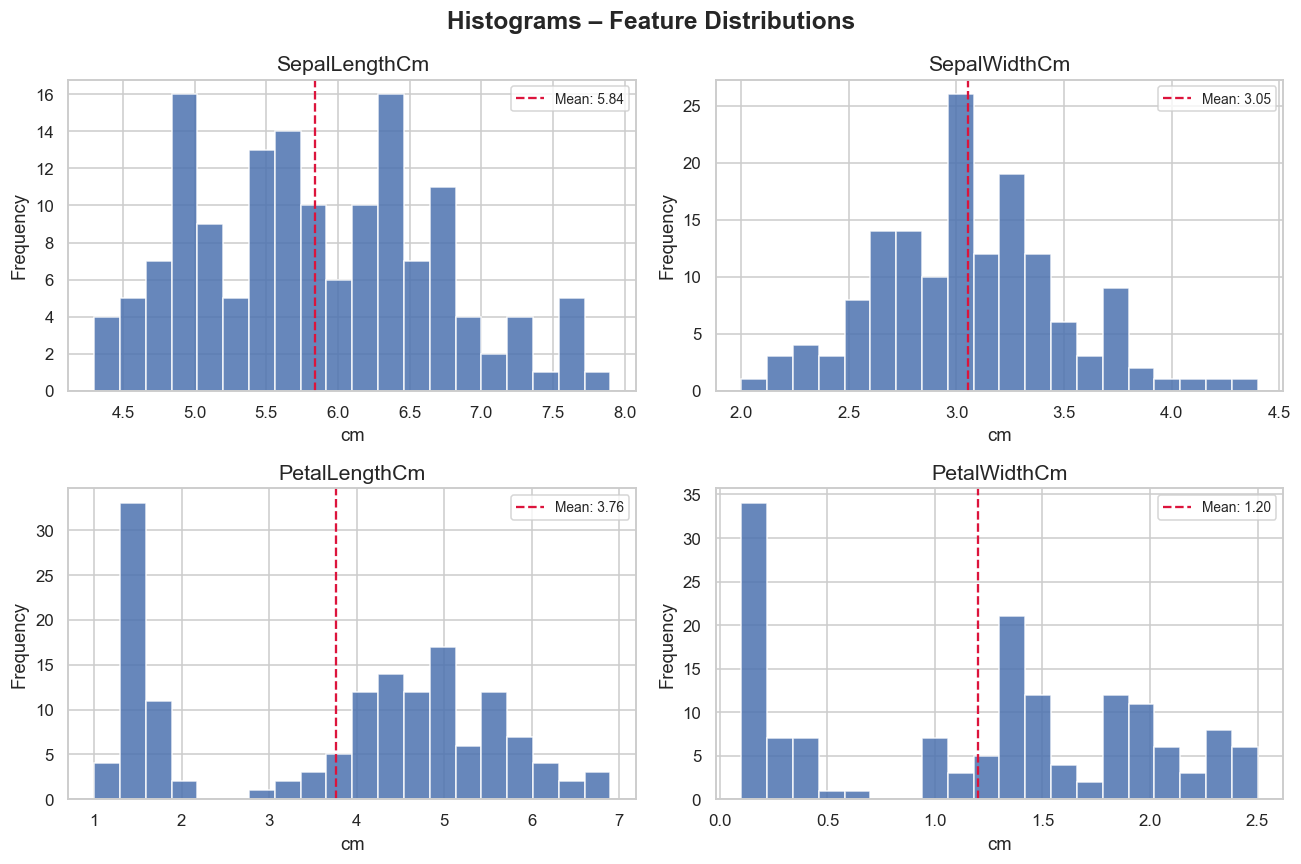

Saved: hist_features.png


In [7]:
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Histograms – Feature Distributions", fontsize=16, fontweight="bold")

for ax, feat in zip(axes.flat, features):
    ax.hist(df[feat], bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(df[feat].mean(), color="crimson", linestyle="--", linewidth=1.5, label=f"Mean: {df[feat].mean():.2f}")
    ax.set_title(feat)
    ax.set_xlabel("cm")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("hist_features.png", bbox_inches="tight")
plt.show()
print("Saved: hist_features.png")


### 2b – Box Plots (overall)

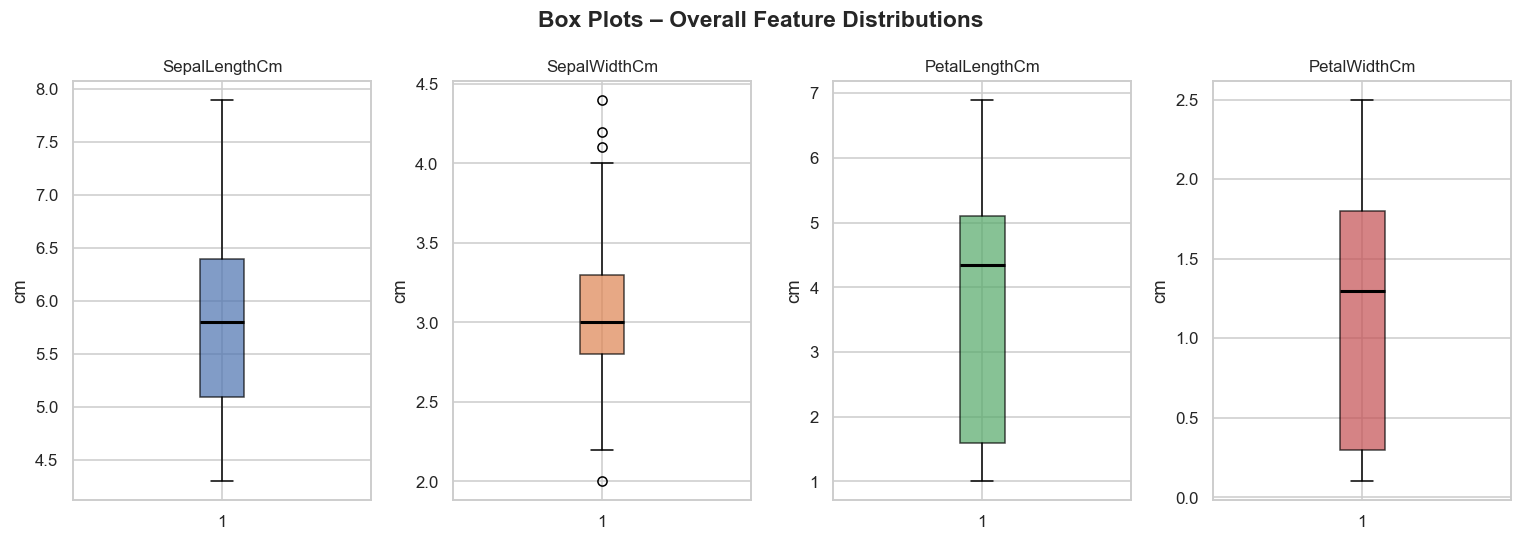

Saved: boxplot_overall.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle("Box Plots – Overall Feature Distributions", fontsize=15, fontweight="bold")

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for ax, feat, color in zip(axes, features, colors):
    ax.boxplot(df[feat], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color="black", linewidth=2))
    ax.set_title(feat, fontsize=11)
    ax.set_ylabel("cm")

plt.tight_layout()
plt.savefig("boxplot_overall.png", bbox_inches="tight")
plt.show()
print("Saved: boxplot_overall.png")


### 2c – Box Plots grouped by Species

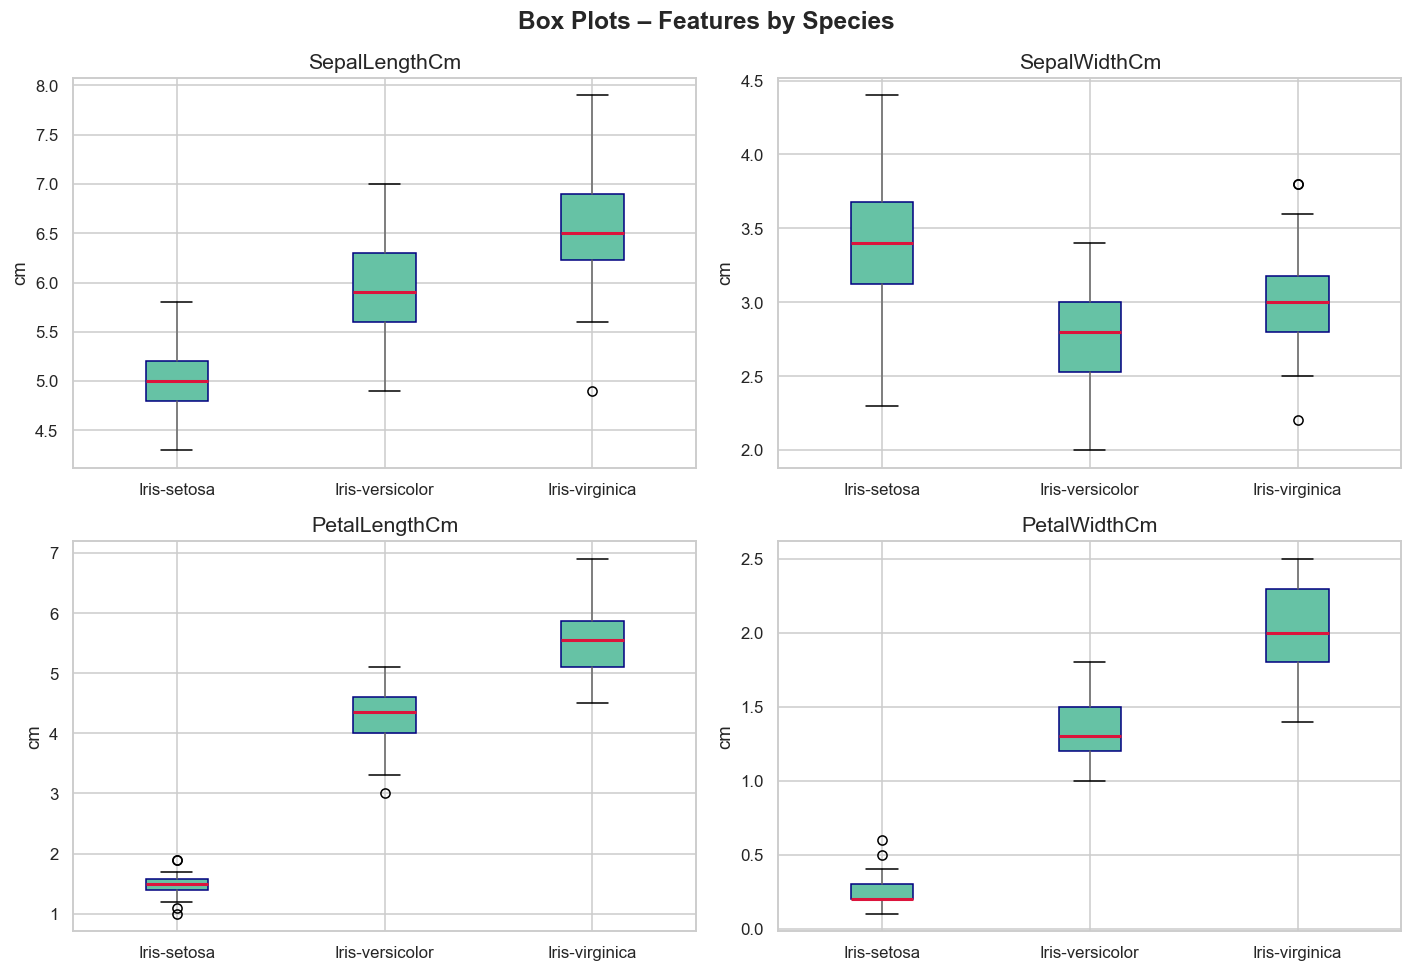

Saved: boxplot_by_species.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Box Plots – Features by Species", fontsize=16, fontweight="bold")

for ax, feat in zip(axes.flat, features):
    df.boxplot(column=feat, by="Species", ax=ax,
               patch_artist=True,
               boxprops=dict(color="navy"),
               medianprops=dict(color="crimson", linewidth=2))
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("cm")

plt.suptitle("Box Plots – Features by Species", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("boxplot_by_species.png", bbox_inches="tight")
plt.show()
print("Saved: boxplot_by_species.png")


## 3 · Bivariate Analysis
### 3a – Scatter Plots


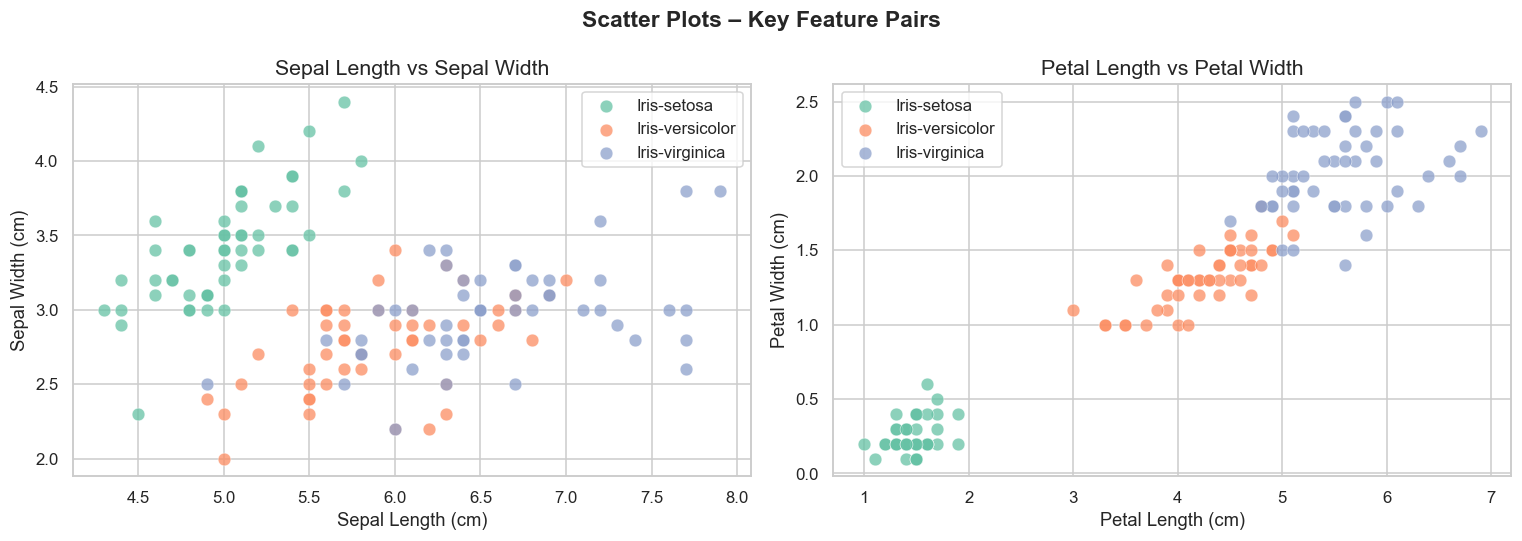

Saved: scatter_bivariate.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Scatter Plots – Key Feature Pairs", fontsize=15, fontweight="bold")

# Sepal
for species, group in df.groupby("Species"):
    axes[0].scatter(group["SepalLengthCm"], group["SepalWidthCm"],
                    label=species, alpha=0.75, edgecolors="white", linewidth=0.4, s=70)
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")
axes[0].set_title("Sepal Length vs Sepal Width")
axes[0].legend()

# Petal
for species, group in df.groupby("Species"):
    axes[1].scatter(group["PetalLengthCm"], group["PetalWidthCm"],
                    label=species, alpha=0.75, edgecolors="white", linewidth=0.4, s=70)
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
axes[1].set_title("Petal Length vs Petal Width")
axes[1].legend()

plt.tight_layout()
plt.savefig("scatter_bivariate.png", bbox_inches="tight")
plt.show()
print("Saved: scatter_bivariate.png")


### 3b – Bar Charts (mean per species)

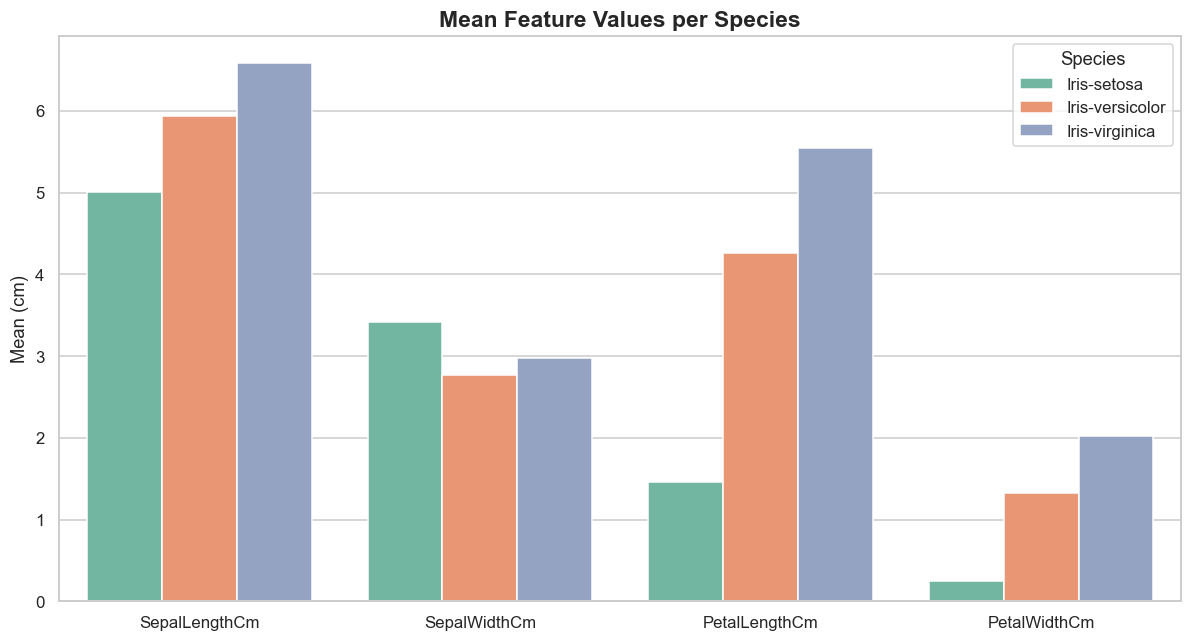

Saved: bar_means.png


In [11]:
means = df.groupby("Species")[features].mean().reset_index()
means_melted = means.melt(id_vars="Species", var_name="Feature", value_name="Mean (cm)")

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=means_melted, x="Feature", y="Mean (cm)",
            hue="Species", ax=ax, palette="Set2", edgecolor="white")

ax.set_title("Mean Feature Values per Species", fontsize=15, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Mean (cm)")
ax.legend(title="Species")

plt.tight_layout()
plt.savefig("bar_means.png", bbox_inches="tight")
plt.show()
print("Saved: bar_means.png")


### 3c – Violin Plots

C:\Users\user\AppData\Local\Temp\ipykernel_22808\911397851.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Species", y=feat, ax=ax,
C:\Users\user\AppData\Local\Temp\ipykernel_22808\911397851.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Species", y=feat, ax=ax,
C:\Users\user\AppData\Local\Temp\ipykernel_22808\911397851.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Species", y=feat, ax=ax,
C:\Users\user\AppData\Local\Temp\ipykernel_22808\911397851.py:5: FutureWarning: 

Passing `pal

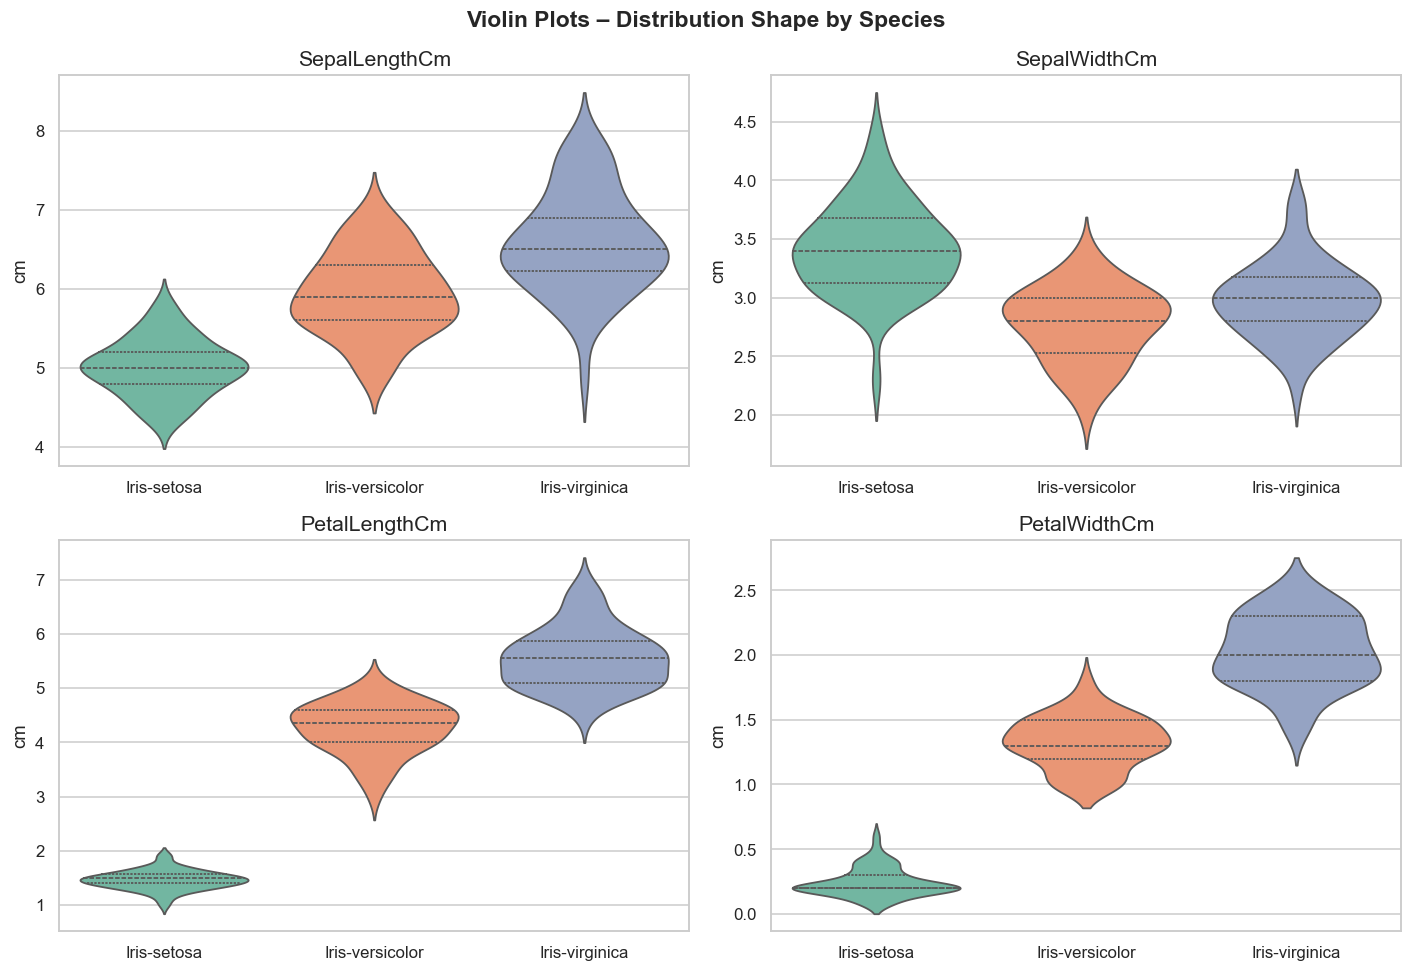

Saved: violin_plots.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Violin Plots – Distribution Shape by Species", fontsize=15, fontweight="bold")

for ax, feat in zip(axes.flat, features):
    sns.violinplot(data=df, x="Species", y=feat, ax=ax,
                   palette="Set2", inner="quartile", linewidth=1.2)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("cm")

plt.tight_layout()
plt.savefig("violin_plots.png", bbox_inches="tight")
plt.show()
print("Saved: violin_plots.png")


## 4 · Correlation Matrix & Heatmap

Correlation Matrix:
               SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm           1.00         -0.11           0.87          0.82
SepalWidthCm           -0.11          1.00          -0.42         -0.36
PetalLengthCm           0.87         -0.42           1.00          0.96
PetalWidthCm            0.82         -0.36           0.96          1.00


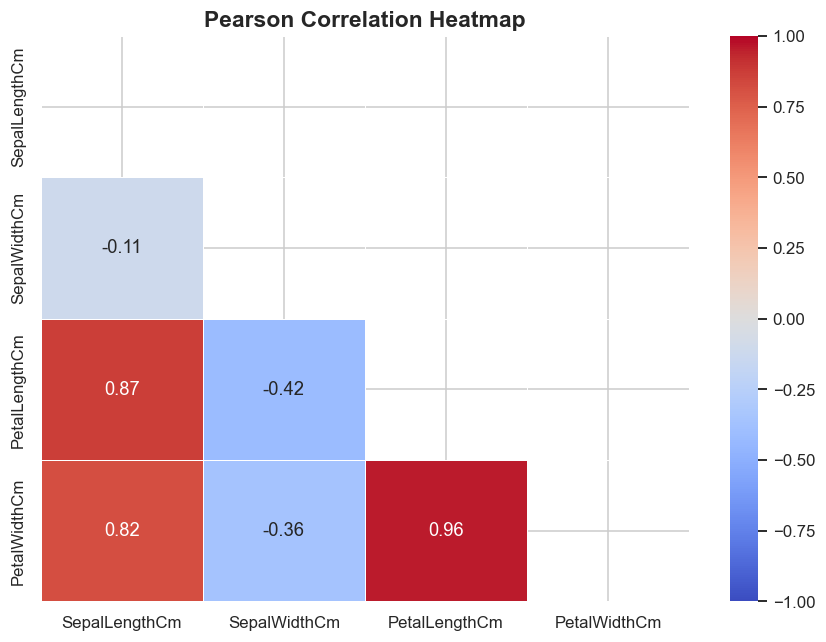

Saved: heatmap.png


In [13]:
corr = df[features].corr().round(2)
print("Correlation Matrix:")
print(corr)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.6, ax=ax, mask=mask,
            vmin=-1, vmax=1, annot_kws={"size": 12})

ax.set_title("Pearson Correlation Heatmap", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap.png", bbox_inches="tight")
plt.show()
print("Saved: heatmap.png")


## 5 · Pair Plot (Multivariate Analysis)

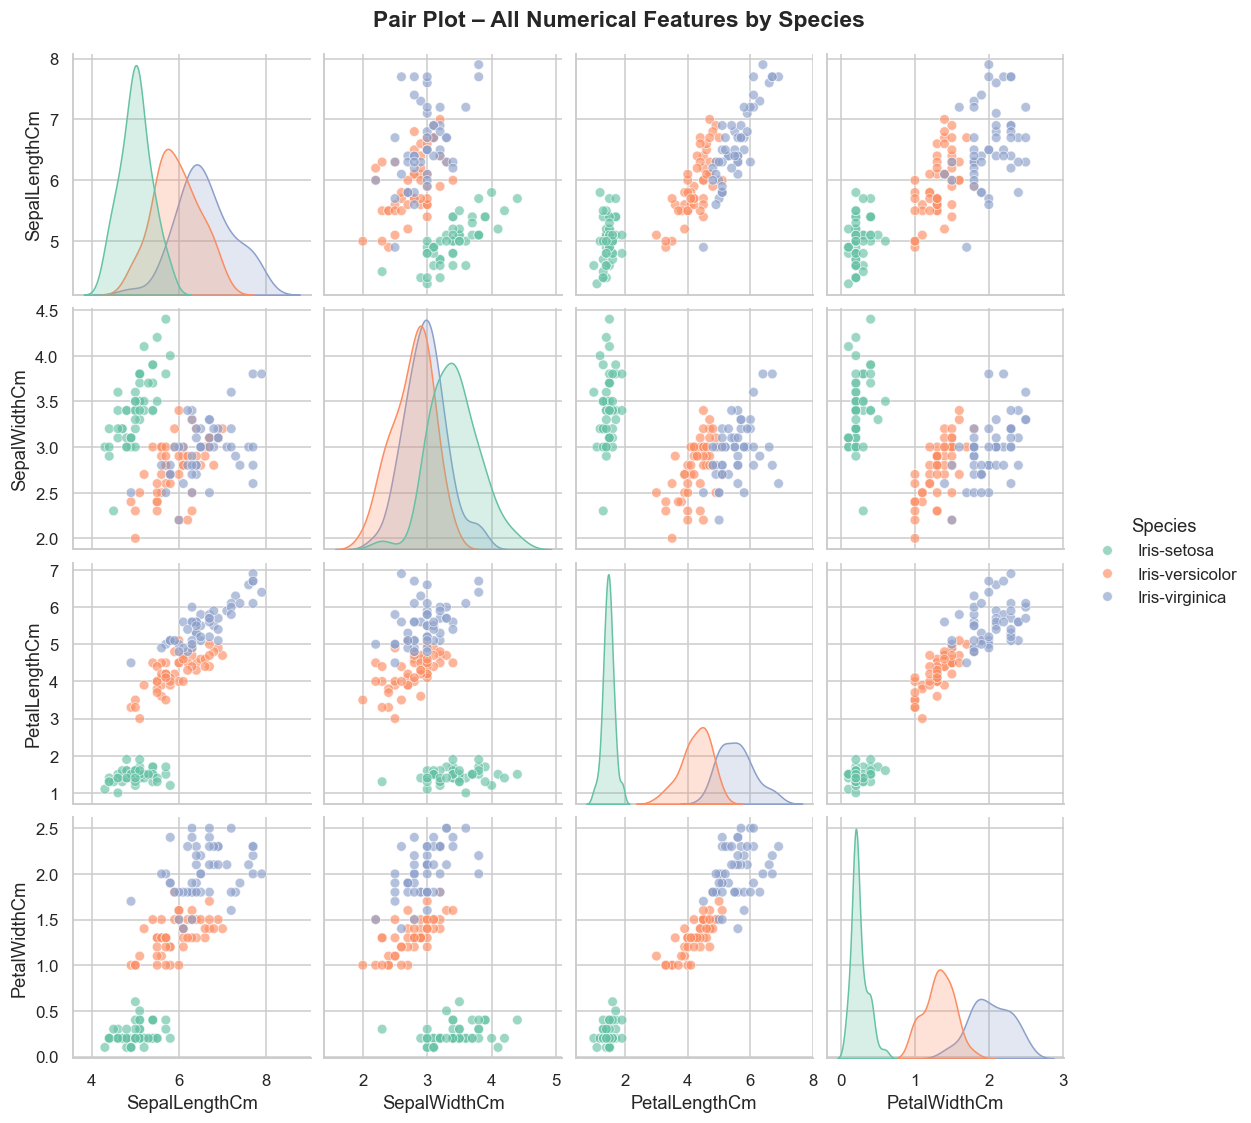

Saved: pairplot.png


In [14]:
pair_grid = sns.pairplot(df, hue="Species", palette="Set2",
                         diag_kind="kde", plot_kws={"alpha": 0.65, "s": 40})
pair_grid.figure.suptitle("Pair Plot – All Numerical Features by Species",
                           y=1.02, fontsize=15, fontweight="bold")

pair_grid.savefig("pairplot.png", bbox_inches="tight")
plt.show()
print("Saved: pairplot.png")


## 6 · Outlier Detection

In [15]:
# IQR-based outlier count per feature
print("=== Outliers (IQR method) ===")
for feat in features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feat] < Q1 - 1.5 * IQR) | (df[feat] > Q3 + 1.5 * IQR)]
    print(f"  {feat}: {len(outliers)} outlier(s)")


=== Outliers (IQR method) ===
  SepalLengthCm: 0 outlier(s)
  SepalWidthCm: 4 outlier(s)
  PetalLengthCm: 0 outlier(s)
  PetalWidthCm: 0 outlier(s)


## 7 · Key Insights Summary

| # | Insight |
|---|---------|
| 1 | **Iris-setosa is linearly separable** from versicolor and virginica on petal dimensions alone. |
| 2 | **Petal Length and Petal Width are strongly correlated** (r ≈ 0.96) — they carry redundant information. |
| 3 | **Petal features are better discriminators** than sepal features across all three species. |
| 4 | **Sepal Width has the lowest inter-species variance** — least useful as a standalone predictor. |
| 5 | **SepalWidthCm contains a few mild outliers** (4 data points beyond 1.5×IQR whiskers). |
| 6 | The pair plot clearly shows **three distinct clusters**, with versicolor and virginica slightly overlapping in petal space. |
| 7 | All four features are approximately **normally distributed** within each species class. |

### ✅ EDA Conclusion
The Iris dataset is clean, balanced, and well-structured. EDA confirms that **petal measurements are the most discriminative features** for species classification. A simple model (e.g. Logistic Regression or KNN) should achieve very high accuracy on this dataset.
